# Personal Trading Performance Analysis

**Goal:** Analyse my real MT4 trade history to identify performance patterns, edge, and areas 
for improvement across EURUSD and GBPUSD.

**Dataset:** 65 closed trades across May–June 2026, including entry/exit prices, P&L, 
commission, volume, and exit reason.

**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

trades = pd.read_csv('../data/mt4_trade_history.csv')
trades.head()

,Position,Login,Symbol,Date,Action,Entry,Reason,Profit,Commission,Swap,Volume,VolumeClosed,Price,StopLoss,TakeProfit
0,92556557,2715093,GBPUSD,2026-05-18T10:25:35,Buy,In,Mobile,-2.50,-2.50,0.0,1.0,0.0,1.33470,NaN,NaN
1,92556557,2715093,GBPUSD,2026-05-18T11:09:44,Sell,Out,SL,47.50,-2.50,0.0,1.0,1.0,1.33520,1.33523,1.33771
2,92582541,2715093,EURUSD,2026-05-18T12:27:16,Sell,In,Mobile,-1.50,-1.50,0.0,0.6,0.0,1.16374,NaN,NaN
3,92582541,2715093,EURUSD,2026-05-18T14:34:35,Buy,Out,SL,-3.30,-1.50,0.0,0.6,0.6,1.16377,1.16371,1.16124
4,93222380,2715093,EURUSD,2026-05-21T10:55:20,Sell,In,Mobile,-1.25,-1.25,0.0,0.5,0.0,1.16061,NaN,NaN


In [2]:
# convert date to datetime
trades['Date'] = pd.to_datetime(trades['Date'])

# separate entry and exit legs
entries = trades[trades['Entry'] == 'In'].copy()
exits = trades[trades['Entry'] == 'Out'].copy()

# group exits by position — sum P&L and commission in case of partial closes
exits_grouped = exits.groupby('Position').agg(
    exit_date=('Date', 'max'),
    exit_reason=('Reason', 'last'),
    gross_profit=('Profit', 'sum'),
    commission=('Commission', 'sum'),
    exit_price=('Price', 'last')
).reset_index()

# merge with entries
closed = entries.merge(exits_grouped, on='Position')
closed['net_profit'] = closed['gross_profit'] + closed['commission']
closed['duration_mins'] = (closed['exit_date'] - closed['Date']).dt.total_seconds() / 60
closed['winner'] = closed['net_profit'] > 0
closed['date'] = closed['Date'].dt.date

# rename for clarity
closed = closed.rename(columns={'Date': 'entry_date', 'Action': 'direction', 
                                 'Price': 'entry_price', 'Symbol': 'symbol',
                                 'Volume': 'volume'})

closed = closed[['Position','symbol','entry_date','exit_date','direction',
                  'entry_price','exit_price','exit_reason','volume',
                  'gross_profit','commission','net_profit','duration_mins','winner']]

print(f"Total closed trades: {len(closed)}")
closed.head()

closed.to_csv('../data/closed_trades.csv', index=False)
print("closed_trades.csv saved")

Total closed trades: 65
closed_trades.csv saved


## Key Performance Metrics

In [3]:
total_trades = len(closed)
winners = closed[closed['winner'] == True]
losers = closed[closed['winner'] == False]

win_rate = len(winners) / total_trades * 100
avg_win = winners['net_profit'].mean()
avg_loss = losers['net_profit'].mean()
rr_ratio = abs(avg_win / avg_loss)
total_pnl = closed['net_profit'].sum()
total_commission = closed['commission'].sum()
largest_win = closed['net_profit'].max()
largest_loss = closed['net_profit'].min()
avg_duration = closed['duration_mins'].mean()

print(f"Total Trades:        {total_trades}")
print(f"Win Rate:            {win_rate:.1f}%")
print(f"Total Net P&L:       ${total_pnl:.2f}")
print(f"Total Commission:    ${total_commission:.2f}")
print(f"Avg Win:             ${avg_win:.2f}")
print(f"Avg Loss:            ${avg_loss:.2f}")
print(f"Risk/Reward Ratio:   {rr_ratio:.2f}")
print(f"Largest Win:         ${largest_win:.2f}")
print(f"Largest Loss:        ${largest_loss:.2f}")
print(f"Avg Trade Duration:  {avg_duration:.0f} mins")

Total Trades:        65
Win Rate:            33.8%
Total Net P&L:       $300.19
Total Commission:    $-93.81
Avg Win:             $58.41
Avg Loss:            $-22.90
Risk/Reward Ratio:   2.55
Largest Win:         $251.20
Largest Loss:        $-70.44
Avg Trade Duration:  151 mins


**Key Metrics Summary:**
- Win rate of 33.8% is intentionally low — the strategy is designed around a 2.55 R:R ratio, 
  meaning winners are on average 2.55x larger than losers. This is a valid and common approach 
  in professional trading.
- $300.19 net profit across 65 trades, after $93.81 in commission.
- Average trade duration of 151 minutes — intraday style, no overnight holding.
- Largest single win ($251.20) vs largest loss ($70.44) confirms asymmetric payoff structure.

## Equity Curve

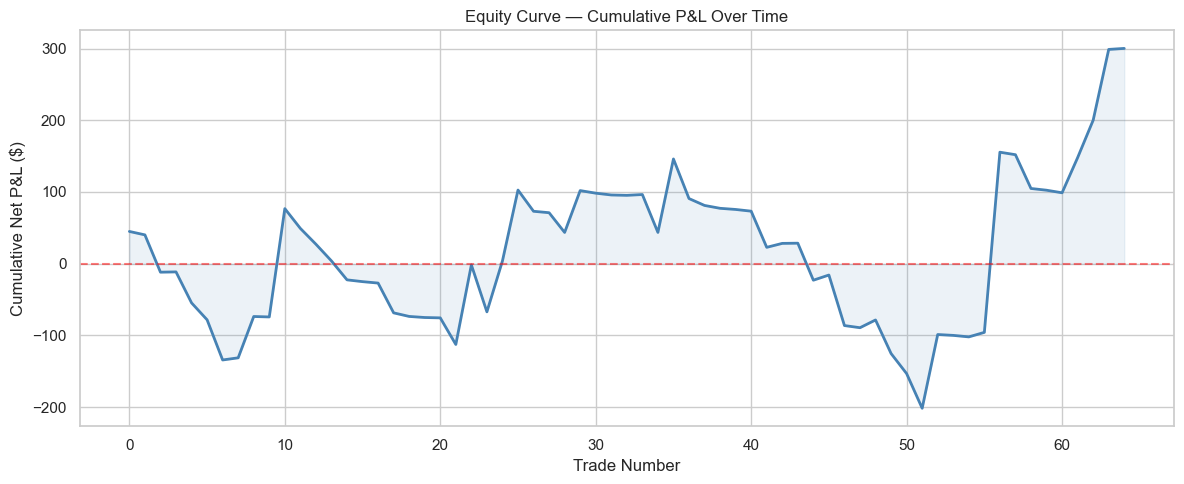

In [4]:
closed_sorted = closed.sort_values('entry_date').reset_index(drop=True)
closed_sorted['cumulative_pnl'] = closed_sorted['net_profit'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(closed_sorted.index, closed_sorted['cumulative_pnl'], 
         color='steelblue', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.fill_between(closed_sorted.index, closed_sorted['cumulative_pnl'], 
                 alpha=0.1, color='steelblue')
plt.title('Equity Curve — Cumulative P&L Over Time')
plt.xlabel('Trade Number')
plt.ylabel('Cumulative Net P&L ($)')
plt.tight_layout()
plt.show()

**Insight:** The equity curve shows three distinct phases — an early drawdown period (trades 
4–10), a choppy mid-section that dips to -$110 around trade 21, and a strong recovery in the 
final phase driven by several large winners. The curve ends at +$300 despite spending a 
significant portion of the period in negative territory, highlighting the importance of 
staying consistent through losing streaks when the R:R ratio is positive.

## Performance by Trade Direction

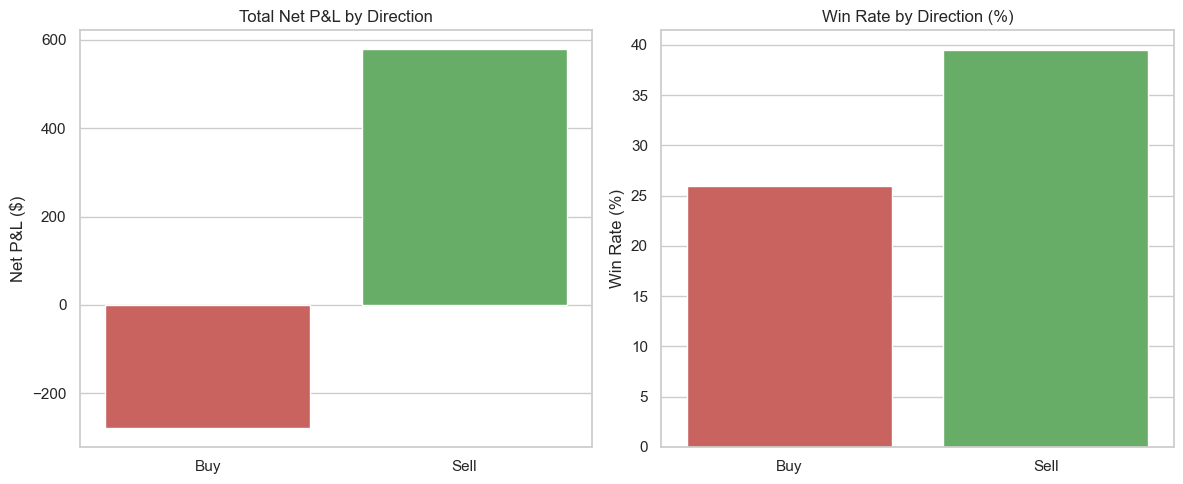

direction  trades  net_pnl  win_rate  avg_profit
      Buy      27  -277.85 25.925926  -10.290741
     Sell      38   578.04 39.473684   15.211579


In [5]:
direction_stats = closed.groupby('direction').agg(
    trades=('net_profit', 'count'),
    net_pnl=('net_profit', 'sum'),
    win_rate=('winner', 'mean'),
    avg_profit=('net_profit', 'mean')
).reset_index()
direction_stats['win_rate'] = direction_stats['win_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=direction_stats, x='direction', y='net_pnl', 
            hue='direction', palette=['#d9534f','#5cb85c'], legend=False, ax=axes[0])
axes[0].set_title('Total Net P&L by Direction')
axes[0].set_ylabel('Net P&L ($)')
axes[0].set_xlabel('')

sns.barplot(data=direction_stats, x='direction', y='win_rate', 
            hue='direction', palette=['#d9534f','#5cb85c'], legend=False, ax=axes[1])
axes[1].set_title('Win Rate by Direction (%)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(direction_stats.to_string(index=False))

**Insight:** The directional bias is striking — Sell trades generated $578 profit at a 39% 
win rate, while Buy trades lost $278 at only 26% win rate. This suggests a clear short bias 
edge in the current market conditions, likely reflecting the bearish EURUSD trend during 
May–June 2026. Buy trades should be taken more selectively or avoided until market 
conditions shift.